   Ozone  Solar.R  Wind  Temp  Month  Day
0   41.0    190.0   7.4    67      5    1
1   36.0    118.0   8.0    72      5    2
2   12.0    149.0  12.6    74      5    3
3   18.0    313.0  11.5    62      5    4
4    NaN      NaN  14.3    56      5    5 

Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64 

44 

     Ozone  Solar.R  Wind  Temp  Month  Day
0     41.0    190.0   7.4    67      5    1
1     36.0    118.0   8.0    72      5    2
2     12.0    149.0  12.6    74      5    3
3     18.0    313.0  11.5    62      5    4
4     23.0    299.0   8.6    65      5    7
..     ...      ...   ...   ...    ...  ...
106   14.0     20.0  16.6    63      9   25
107   30.0    193.0   6.9    70      9   26
108   14.0    191.0  14.3    75      9   28
109   18.0    131.0   8.0    76      9   29
110   20.0    223.0  11.5    68      9   30

[111 rows x 6 columns] 

33    135.0
76    168.0
Name: Ozone, dtype: float64 

     Ozone  Solar.R  Wind  Temp  M

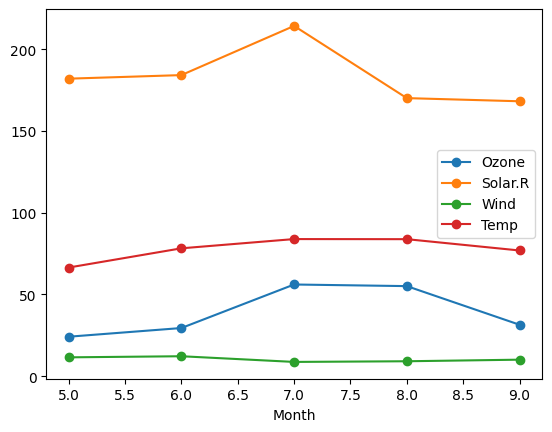

In [11]:
#1
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/airquality.csv")
print(df.head(), '\n')

#2
print(df.isnull().sum(), '\n')
print(df.isna().sum(axis = 1).sum(), '\n')

#3
df_cleaned = df.dropna()
df_cleaned = df_cleaned.reset_index(drop = True)
print(df_cleaned, '\n')

#4
ozone = df_cleaned['Ozone']
Q1 = ozone.quantile(0.25)
Q3 = ozone.quantile(0.75)
IQR = Q3 - Q1

outliers = ozone.loc[(ozone < Q1 - IQR * 1.5) | (ozone > Q3 + IQR * 1.5)]
print(outliers, '\n')

df_cleaned = df_cleaned.loc[~df_cleaned['Ozone'].isin(outliers)]
df_cleaned = df_cleaned.reset_index(drop = True)
print(df_cleaned, '\n')

#5
result = df_cleaned.groupby('Month')[['Ozone', 'Solar.R', 'Wind', 'Temp']].mean()
print(result, '\n')

result.plot(marker = 'o')
plt.show()


In [15]:
import pandas as pd

emp = pd.read_csv("../data/emp.csv")
dept = pd.read_csv("../data/dept.csv")
print(emp.head(), '\n')
print(dept.head(), '\n')

df = emp.merge(dept, on = 'DEPTNO')
print(df.head(), '\n')

print(df.pivot_table(index = "LOC", columns = "JOB", values = "SAL", aggfunc = 'sum'), '\n')

print(df.pivot_table(index = "DNAME", columns = 'JOB', values = 'ENAME', aggfunc = 'count'))

   EMPNO   ENAME       JOB     MGR    HIREDATE   SAL    COMM  DEPTNO
0   7369   SMITH     CLERK  7902.0  1980-12-17   800     NaN      20
1   7499   ALLEN  SALESMAN  7698.0  1981-02-20  1600   300.0      30
2   7521    WARD  SALESMAN  7698.0  1981-02-22  1250   500.0      30
3   7566   JONES   MANAGER  7839.0  1981-04-02  2975     NaN      20
4   7654  MARTIN  SALESMAN  7698.0  1981-08-28  1250  1400.0      30 

   DEPTNO       DNAME       LOC
0      10  ACCOUNTING  NEW YORK
1      20    RESEARCH    DALLAS
2      30       SALES   CHICAGO
3      40  OPERATIONS    BOSTON
4      70    BRANCH_1     SEOUL 

   EMPNO   ENAME       JOB     MGR    HIREDATE   SAL    COMM  DEPTNO  \
0   7369   SMITH     CLERK  7902.0  1980-12-17   800     NaN      20   
1   7499   ALLEN  SALESMAN  7698.0  1981-02-20  1600   300.0      30   
2   7521    WARD  SALESMAN  7698.0  1981-02-22  1250   500.0      30   
3   7566   JONES   MANAGER  7839.0  1981-04-02  2975     NaN      20   
4   7654  MARTIN  SALESMAN  76